# EDA OF US HEALTH INSURANCE DATASET



# 1: import Library 

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2: Load Dataset

In [10]:
df=pd.read_csv('loan_prediction_problem.csv')

In [11]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [12]:
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


# 3: Summary Of Dataset

In [13]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


# 4: Missing Values

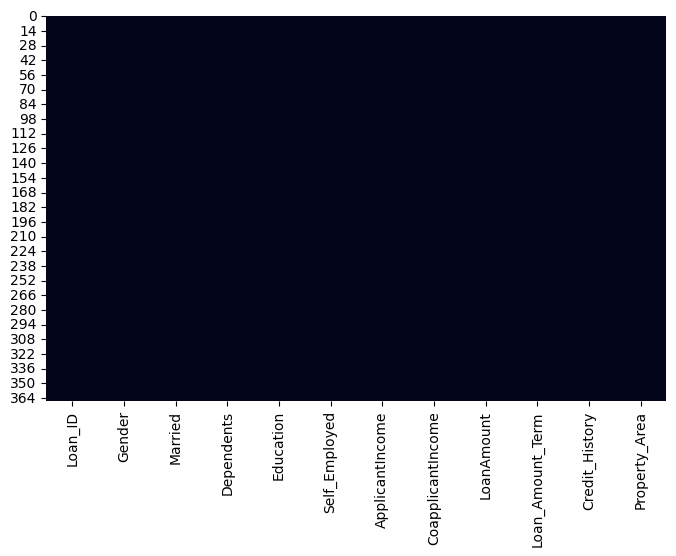

In [55]:
# Visualize the data
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [40]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [18]:
df.value_counts().sum()

289

In [39]:
for col in df.columns:
    if df[col].dtype == 'object':  # Categorical column
        df[col] = df[col].fillna(df[col].mode()[0])
    else:  # Numerical column
        df[col] = df[col].fillna(df[col].mean())


# 5: Checking Duplicates

In [20]:
df.duplicated().sum()

0

In [41]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

# 6: univarite Analysis

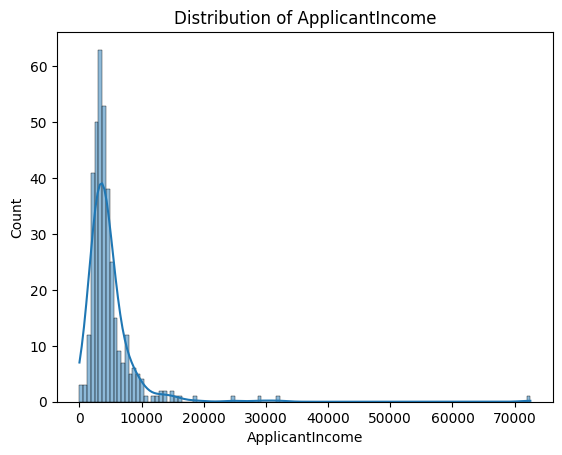

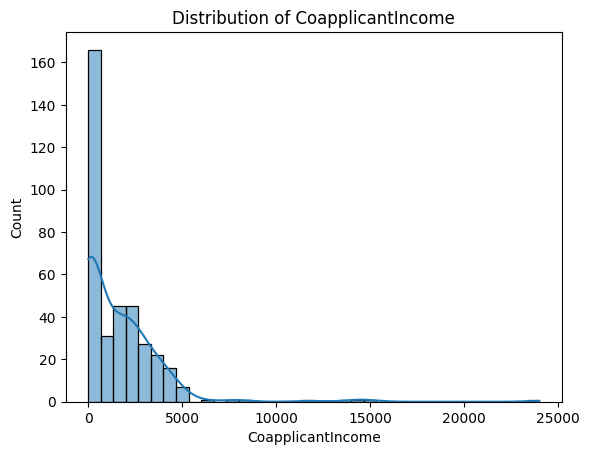

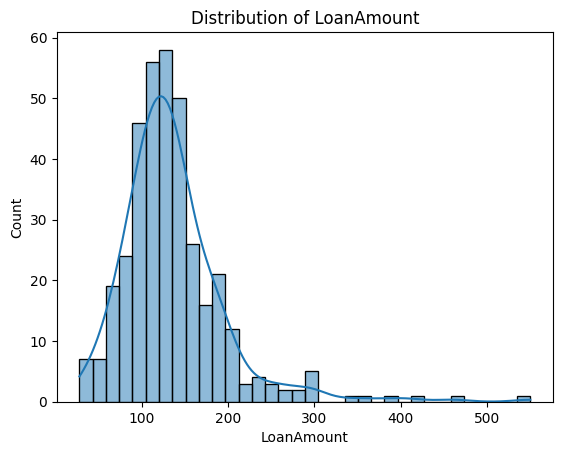

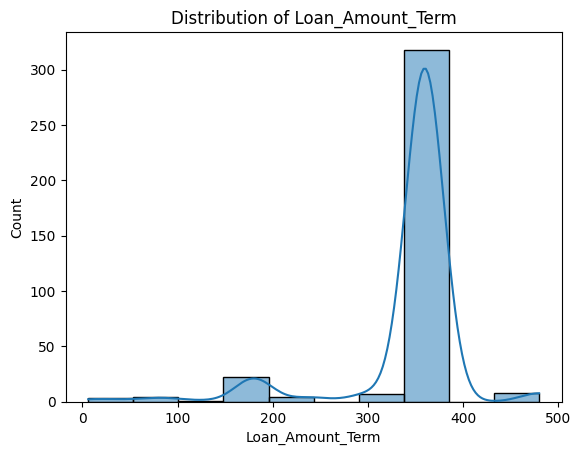

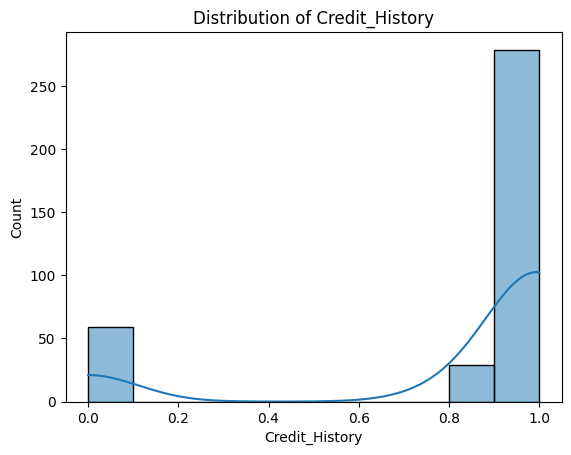

In [42]:
uni_colums=['ApplicantIncome','CoapplicantIncome', 'LoanAmount','Loan_Amount_Term','Credit_History']
for col in uni_colums:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# 8. Bivariate Analysis

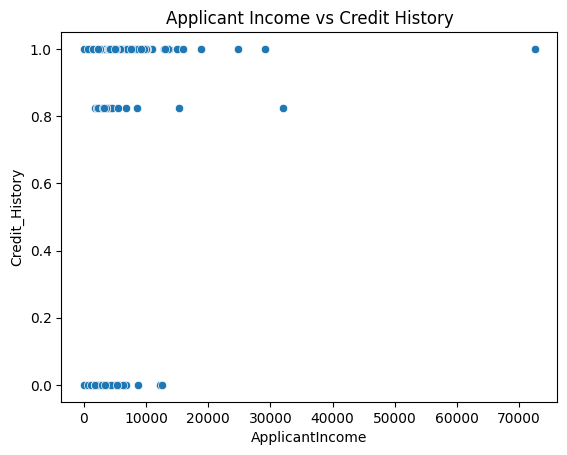

In [43]:
plt.figure()
sns.scatterplot(x='ApplicantIncome', y='Credit_History', data=df)
plt.title('Applicant Income vs Credit History')
plt.show()

# 9. Correlation Heatmap

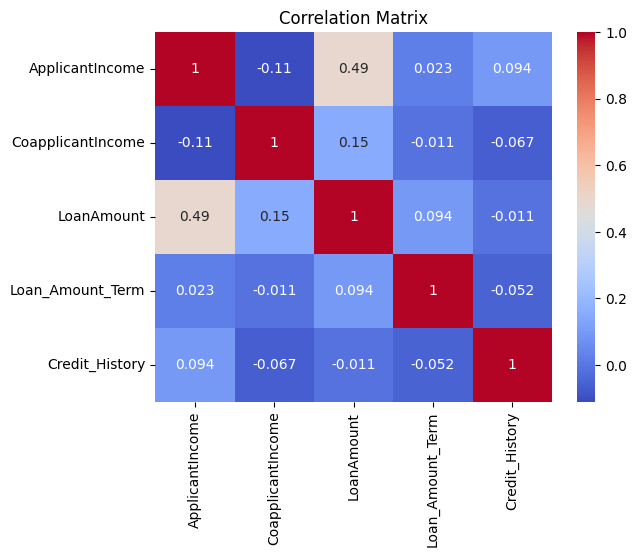

In [44]:
plt.figure()
numeric_df = df.select_dtypes(include=['number'])  # Select only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 10. Outlier Detection

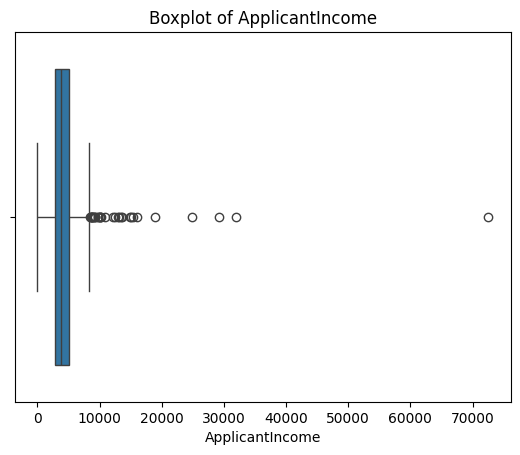

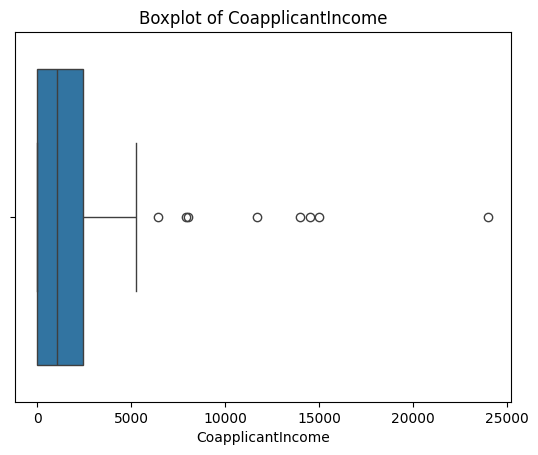

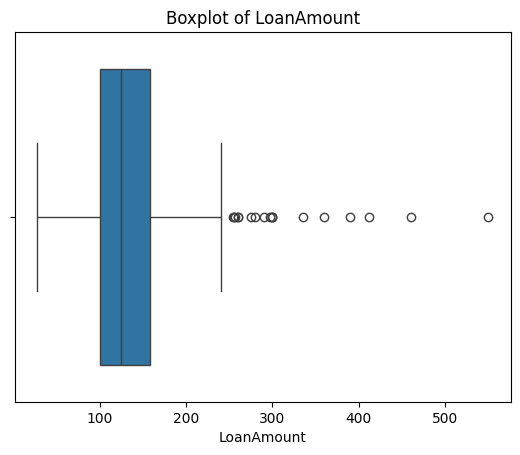

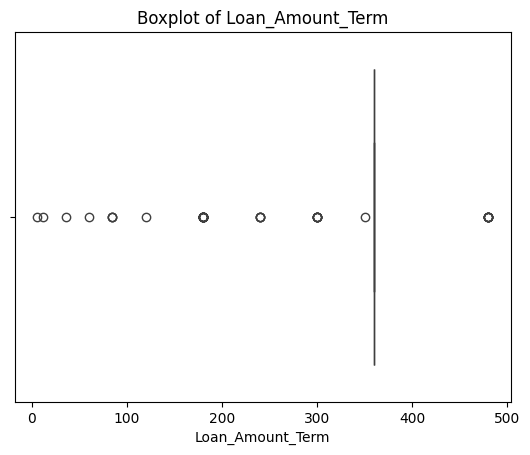

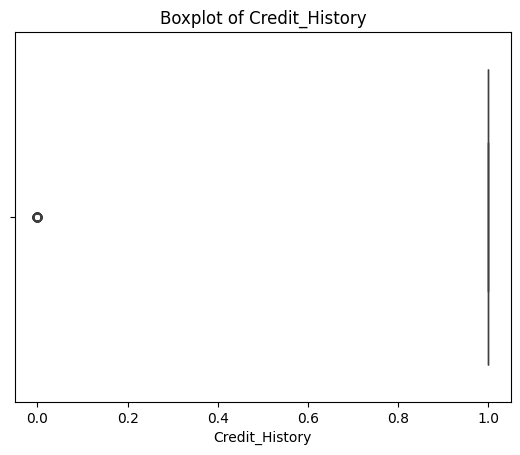

In [38]:
num_cols = numeric_df.columns  # Define num_cols as the numeric columns
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


# 1. IQR Method (Interquartile Range)

In [53]:
Q1 = df['CoapplicantIncome'].quantile(0.25)
Q3 = df['CoapplicantIncome'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

IQR_outliers = df[(df['CoapplicantIncome'] < lower_limit) | (df['CoapplicantIncome'] > upper_limit)]
print(f"Original data rows: {len(df)}")
print(f"Data after removing outliers: {len(IQR_outliers)}")
print(IQR_outliers)


Original data rows: 367
Data after removing outliers: 8
      Loan_ID  Gender Married Dependents     Education Self_Employed  \
18   LP001108    Male     Yes          0      Graduate            No   
25   LP001153    Male      No          0      Graduate            No   
85   LP001452    Male     Yes          2      Graduate            No   
123  LP001652    Male      No          0      Graduate            No   
230  LP002294    Male      No          0      Graduate            No   
237  LP002325    Male     Yes          2  Not Graduate            No   
284  LP002570  Female     Yes          2      Graduate            No   
351  LP002901    Male      No          0      Graduate            No   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
18              9226               7916    2.692400             360.0   
25                 0              24000    0.194986             360.0   
85              4635               8000   -0.560811             180.0   
123

# 2. Z-Score ke baad

In [54]:
from scipy.stats import zscore

df['LoanAmount'] = zscore(df['LoanAmount'])

Z_score_outliers = df[(df['LoanAmount'] > 3) | (df['LoanAmount'] < -3)]
print(f"Original data rows: {len(df)}")
print(f"Data after removing outliers: {len(Z_score_outliers)}")
print(Z_score_outliers)


Original data rows: 367
Data after removing outliers: 6
      Loan_ID  Gender Married Dependents Education Self_Employed  \
81   LP001428    Male     Yes         3+  Graduate            No   
91   LP001483    Male     Yes         3+  Graduate            No   
143  LP001791    Male     Yes          0  Graduate           Yes   
189  LP002059    Male     Yes          2  Graduate            No   
194  LP002077    Male     Yes          1  Graduate            No   
284  LP002570  Female     Yes          2  Graduate            No   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
81             72529                  0    3.678221             360.0   
91             13518                  0    4.171132             360.0   
143            32000                  0    6.799989             360.0   
189             7874               3967    3.283893             360.0   
194            10000               2690    4.532600             360.0   
284            10000         